# Importing libraries

In [1]:
import torchvision.datasets as datasets
from torch.utils.data import TensorDataset, DataLoader
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix ,ConfusionMatrixDisplay 
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as f
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score
import numpy as np
import time
import seaborn as sns

# Logistic regression

## Functions used in the logistic regression

In [2]:
# Segmoid activation function
def sigmoid(z):
    return 1 / (1 + torch.exp(-z))
# Predection calculation
def predict(X):
    return sigmoid(X @ W + b)
# Cross Entropy loss function
def binary_cross_entropy(y_hat, y):
    eps = 1e-8
    return -torch.mean(y * torch.log(y_hat + eps) + (1 - y) * torch.log(1 - y_hat + eps))
# Gradient Descent Application function
def gradient_descent(train_loader, alpha=0.01, epochs=100):
    global W,b
    for epoch in range(epochs):
        total_loss = 0.0

        for X_batch, y_batch in train_loader_binary:
            y_batch = y_batch.view(-1, 1).float()
            X_batch = X_batch.view(X_batch.size(0), -1)

            y_hat = predict(X_batch)
            loss = binary_cross_entropy(y_hat, y_batch)
            with torch.no_grad():
                W -= alpha * (X_batch.T @ (y_hat - y_batch)) / X_batch.size(0)
                b -= alpha * torch.mean(y_hat - y_batch)
# Calculate metrics
def calculate_metrics(y_true,y_hat):
    acc = accuracy_score(y_true, y_hat)
    prec = precision_score(y_true, y_hat, average='macro')
    rec = recall_score(y_true, y_hat, average='macro')
    f1 = f1_score(y_true, y_hat, average='macro')
    return acc,prec,rec,f1

## Downloading MNIST dataset

In [3]:
dataset = datasets.MNIST(root='./data', train=True, download=True)
X = dataset.data.numpy()
y = dataset.targets.numpy()
# Normalization
X = X / 255.0
# Flattening
X_flat = X.reshape(-1, 28*28)

100%|██████████| 9.91M/9.91M [00:00<00:00, 53.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.08MB/s]


## Splitting the data into 60% train, 20% validation and 20% test

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_flat, y, test_size=0.4, stratify=y, random_state=3
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=3
)

## Preproccessing the data into tensors and dataloaders form

In [5]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

# batching the data
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Applyin mask to take into account only zeros and ones from the dataset.

In [6]:
train_mask = (y_train_t == 0) | (y_train_t == 1)
val_mask   = (y_val_t == 0)   | (y_val_t == 1)
test_mask  = (y_test_t == 0)  | (y_test_t == 1)

train_dataset_binary = TensorDataset(X_train_t[train_mask],y_train_t[train_mask])
val_dataset_binary   = TensorDataset(X_val_t[val_mask], y_val_t[val_mask])
test_dataset_binary  = TensorDataset(X_test_t[test_mask], y_test_t[test_mask])

train_loader_binary = DataLoader(train_dataset_binary, batch_size=64, shuffle=True)
val_loader_binary   = DataLoader(val_dataset_binary, batch_size=64, shuffle=False)
test_loader_binary  = DataLoader(test_dataset_binary, batch_size=64, shuffle=False)

input_dim = 784

## Training the logistic model and using validation set to benchmark it

In [7]:
W = torch.randn(input_dim, 1) 
b = torch.zeros(1)
st = time.time()
gradient_descent(train_loader_binary,0.01,60) 
en = time.time()
logistic_time = en-st
print(f"Training time: {logistic_time}")
all_preds = []
all_labels = []
total_loss=0
with torch.no_grad():
    for X_batch, y_batch in val_loader_binary:
        X_batch = X_batch.view(X_batch.size(0), -1)
        y_batch= y_batch.view(-1, 1).float()
            
        y_pred = predict(X_batch)
            
        loss = binary_cross_entropy(y_pred, y_batch)
        total_loss += loss.item()
            
        preds = (y_pred >= 0.5).int()
        all_preds.append(preds)
        all_labels.append(y_batch.int())
    
    all_preds = torch.cat(all_preds).flatten()
    all_labels = torch.cat(all_labels).flatten().float()
    accuracy_logistic, precision_logistic, recall_logistic, f1_logistic = calculate_metrics(all_labels, all_preds)
    print(f"Accuracy: {accuracy_logistic}")
    print(f"Precision: {precision_logistic}")
    print(f"recall: {recall_logistic}")
    print(f"f1: {f1_logistic}")

Training time: 8.204302310943604
Accuracy: 0.995260663507109
Precision: 0.9953465048641059
recall: 0.995137942096399
f1: 0.995239706711788


# Softmax regression

## Functions used in Softmax regression

In [8]:
def softmax(z):
    exp_z = torch.exp(z - torch.max(z, dim=1, keepdim=True)[0]) 
    return exp_z / torch.sum(exp_z, dim=1, keepdim=True)

def predict_soft(X):
    return softmax(X @ W + b)
    
#Cross-Entropy Loss
def cross_entropy_soft(y_hat, y):
    eps = 1e-8
    y_one_hot = torch.zeros_like(y_hat)
    y_one_hot[torch.arange(y.size(0)), y] = 1
    return -torch.mean(torch.sum(y_one_hot * torch.log(y_hat + eps), dim=1))
# gradient_descent for softmax
def gradient_descent_softmax(train_loader, alpha=0.01, epochs=1):
    global W, b
    for i in range(epochs):    
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.view(X_batch.size(0), -1)
            y_batch = y_batch.view(-1)
            
            y_hat = predict(X_batch)
            y_one_hot = torch.zeros_like(y_hat)
            y_one_hot[torch.arange(y_batch.size(0)), y_batch] = 1
            
            grad_W = X_batch.T @ (y_hat - y_one_hot) / X_batch.size(0)
            grad_b = torch.mean(y_hat - y_one_hot, dim=0)
            
            with torch.no_grad():
                W -= alpha * grad_W
                b -= alpha * grad_b

## Softmax regression architecture

In [9]:
class SoftmaxBuiltIn(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    
    def forward(self, x):
        return self.linear(x)

input_dim = X_train_t.shape[1]
num_classes = 10
model = SoftmaxBuiltIn(input_dim, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## Initializing weights and bias again to random and zero and training the softmax and benchmarking it using validation set

In [10]:
W = torch.randn(input_dim, num_classes) 
b = torch.zeros(num_classes)
st = time.time()
gradient_descent_softmax(train_loader,0.01,60)
en = time.time()
softmax_time = en - st
print(f"Training time: {softmax_time}")
# -------------------validaton-----------------
all_preds = []
all_labels = []
total_loss=0
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.view(X_batch.size(0), -1)
        y_batch = y_batch.view(-1).long()
            
        y_pred = predict_soft(X_batch)
            
        loss = cross_entropy_soft(y_pred, y_batch)
        total_loss += loss.item()
            
        preds = torch.argmax(y_pred, dim=1)
        all_preds.append(preds)
        all_labels.append(y_batch.long())
    
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
accuracy_softmax, precision_softmax, recall_softmax, f1_softmax = calculate_metrics(all_labels, all_preds)
print(f"Accuracy: {accuracy_softmax}")
print(f"Precision: {precision_softmax}")
print(f"recall: {recall_softmax}")
print(f"f1: {f1_softmax}")

Training time: 44.07285833358765
Accuracy: 0.85925
Precision: 0.8576018692879608
recall: 0.857191910737512
f1: 0.8571495705305724


# Neural Network

## Neural network architecture

In [11]:
class NeuralNetworkArchitecture(nn.Module):
    def __init__(self, input_size, output_size, hidden_layers=[150, 200, 300], init_type='xavier'):
        super(NeuralNetworkArchitecture, self).__init__()

        # Defining hidden layers
        self.layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        in_features = input_size        
        for h in hidden_layers:
            self.layers.append(nn.Linear(in_features, h))
            self.batch_norms.append(nn.BatchNorm1d(h))
            self.dropouts.append(nn.Dropout(p=0.2))
            in_features = h            

        # Output layer
        self.output = nn.Linear(in_features, output_size)

        # Initialize weights
        self.weights_initialization(init_type)

    # Forward pass using ReLU as activation function
    def forward(self, x):
        for layer, bn, dropout in zip(self.layers, self.batch_norms, self.dropouts):
            x = layer(x)       #linear transformation 
            x = bn(x)          #normalize output
            x = f.relu(x)      #apply ReLU activation
            x = dropout(x)     #creation of dropout layer
        x = self.output(x)      
        return x
 

    # Weight initialization
    def weights_initialization(self, init_type):
        all_layers = list(self.layers) + [self.output]
        for layer in all_layers:
            if isinstance(layer, nn.Linear):
                if init_type.lower() == 'xavier':
                    nn.init.xavier_uniform_(layer.weight)
                elif init_type.lower() == 'he':
                    nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)


## Function used to test the model on a specific data

In [12]:
def test_model(model, test_data,device):
    model.to(device)
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for xb, yb in test_data:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model.forward(xb)
            preds = outputs.argmax(dim=1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(yb.cpu().numpy())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    return y_pred,y_true

## Function used to train the NN model

In [13]:
def train_model(
    model, train_loader, val_loader, epochs=100, lr=0.01,
    wait_epochs=10,  # number of epochs to wait before early stopping
     device=None
):  
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # Store loss and accuracy for each epoch for later plotting
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_loss = float('inf')
    best_val_acc = float('inf')
    best_weights = model.state_dict() 
    epochs_no_improve = 0

    for epoch in range(epochs):
        # Training
        model.train()
        total_train_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model.forward(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * xb.size(0)
            y_pred = outputs.argmax(dim=1)
            correct += (y_pred == yb).sum().item()
            total += yb.size(0)

        train_loss = total_train_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        total_val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model.forward(xb)
                loss = criterion(outputs, yb)
                total_val_loss += loss.item() * xb.size(0)
                y_pred = outputs.argmax(dim=1)
                correct += (y_pred == yb).sum().item()
                total += yb.size(0)

        val_loss = total_val_loss / total
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(f"Epoch {epoch+1}:  "
        f"Train Loss: {train_loss:.4f} , Val Loss: {val_loss:.4f} , "
        f"Train Acc: {train_acc:.4f} , Val Acc: {val_acc:.4f}")

         
        # Early Stopping

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_weights = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= wait_epochs:
            print(f"\nEarly stopping at epoch {epoch+1}")
            model.load_state_dict(best_weights)
            break
    print(f"\n Val loss : {best_val_loss}")
    print(f"\n Val Acc : {best_val_acc}")
    y_pred,y_true=test_model(model, test_loader,device)
    return model, train_losses, val_losses, train_accs, val_accs,y_pred,y_true


## Training the NN model and benchmarking it using validation set

In [14]:
input_size = X_flat.shape[1]        
output_size = len(np.unique(y))
model = NeuralNetworkArchitecture(input_size, output_size)
st = time.time()
model,train_losses, val_losses, train_accs, val_accs,y_pred,y_true= train_model(model, train_loader, val_loader)
en = time.time()
NN_time = en - st
print(f"Training time: {NN_time}")
accuracy_NN, precision_NN, recall_NN, f1_NN = calculate_metrics(y_true, y_pred)
print(f"Accuracy: {accuracy_NN}")
print(f"Precision: {precision_NN}")
print(f"recall: {recall_NN}")
print(f"f1: {f1_NN}")

Epoch 1:  Train Loss: 0.8466 , Val Loss: 0.3452 , Train Acc: 0.7359 , Val Acc: 0.9002
Epoch 2:  Train Loss: 0.4266 , Val Loss: 0.2511 , Train Acc: 0.8707 , Val Acc: 0.9257
Epoch 3:  Train Loss: 0.3470 , Val Loss: 0.2145 , Train Acc: 0.8940 , Val Acc: 0.9351
Epoch 4:  Train Loss: 0.3067 , Val Loss: 0.1947 , Train Acc: 0.9074 , Val Acc: 0.9391
Epoch 5:  Train Loss: 0.2765 , Val Loss: 0.1755 , Train Acc: 0.9149 , Val Acc: 0.9448
Epoch 6:  Train Loss: 0.2600 , Val Loss: 0.1632 , Train Acc: 0.9195 , Val Acc: 0.9482
Epoch 7:  Train Loss: 0.2385 , Val Loss: 0.1555 , Train Acc: 0.9273 , Val Acc: 0.9509
Epoch 8:  Train Loss: 0.2250 , Val Loss: 0.1474 , Train Acc: 0.9303 , Val Acc: 0.9531
Epoch 9:  Train Loss: 0.2163 , Val Loss: 0.1390 , Train Acc: 0.9338 , Val Acc: 0.9553
Epoch 10:  Train Loss: 0.2076 , Val Loss: 0.1326 , Train Acc: 0.9360 , Val Acc: 0.9575
Epoch 11:  Train Loss: 0.1986 , Val Loss: 0.1307 , Train Acc: 0.9391 , Val Acc: 0.9581
Epoch 12:  Train Loss: 0.1900 , Val Loss: 0.1236 , T

| Model                     | Training Time (s) | Accuracy | Precision | Recall | F1 Score | Computational Complexity |
|---------------------------|------------------:|-----------|------------|---------|-----------|---------------------------|
| Logistic Regression       | 6.99             | 0.9929    | 0.9929     | 0.9929  | 0.9929    | **O(n)** |
| Softmax Regression        | 37.19            | 0.8628    | 0.8609     | 0.8606  | 0.8605    | **O(n × k)** |
| Neural Network (L layers) | 92.73            | 0.9697    | 0.9694     | 0.9694  | 0.9694    | **O(n·h₁ + h₁·h₂ + … + h<sub>L−1</sub>·h<sub>L</sub> + h<sub>L</sub>·k)** |


# When to use each model?
- Use logistic regression if you want to know if the test value is from someclass or not (You can't dedict which class if it's not the wanted class).
- Use Softmax regresion if you want to classify each value to a class but you don't care that much about accuracy and your concern is running time.
- Use Neural Network unlinke softmax your concern now is the accuracy and you don't care about running time.

# Using the best model (Neural Network) to answer the test set

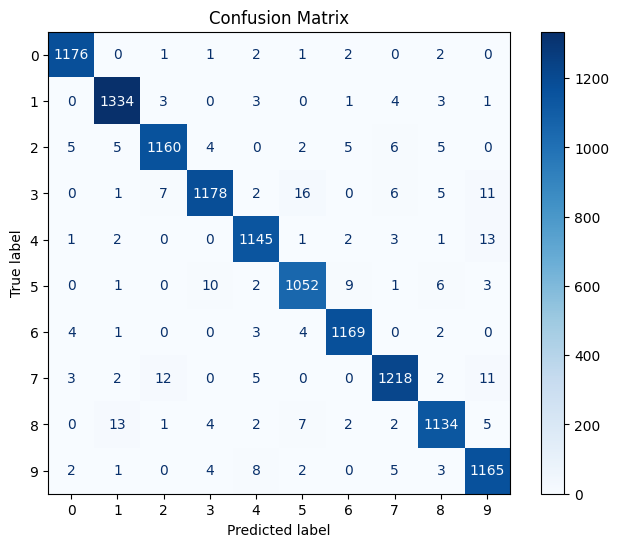

In [15]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title('Confusion Matrix')
plt.show()

# Analyzing missclassified examples

| True Digit | Often Mistaken For |
| ---------- | ------------------ |
| **0**      | 2, 3, 6, 8, 9      |
| **1**      | 2, 4, 7            |
| **2**      | 3, 5, 8            |
| **3**      | 2, 5, 8, 9         |
| **4**      | 9, 7               |
| **5**      | 3, 8               |
| **6**      | 0, 8               |
| **7**      | 2, 3, 9            |
| **8**      | 3, 5, 9            |
| **9**      | 4, 7, 8            |

> Notes
> - Most predictions are correct, the model is very accurate.
> - Errors happen between digits that look like, not random numbers.
> - Digits 1, 6, and 0 are recognized almost perfectly.

# Limitations
- It doesn’t know order or structure
- It can’t remember past inputs
- Doesn’t scale well to very high dimensional data

## That's why we went through the CNNs to solve these issues in normal NNs